In [1]:
# Cell 1: Setup
import math, random, time, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA H200


In [2]:
# Cell 2: Load WavTokenizer
from huggingface_hub import hf_hub_download
from decoder.pretrained import WavTokenizer

HF_REPO = "novateur/WavTokenizer"
VARIANT = "320"
VARIANTS = {
    "600": ("WavTokenizer_small_600_24k_4096.ckpt",
            "configs/wavtokenizer_smalldata_frame40_3s_nq1_code4096_dim512_kmeans200_attn.yaml"),
    "320": ("WavTokenizer_small_320_24k_4096.ckpt",
            "configs/wavtokenizer_smalldata_frame75_3s_nq1_code4096_dim512_kmeans200_attn.yaml"),
}

ckpt_name, cfg_path = VARIANTS[VARIANT]
ckpt_path = hf_hub_download(repo_id=HF_REPO, filename=ckpt_name)
print(f"Variant: {VARIANT}\nConfig: {cfg_path}\nCheckpoint: {ckpt_name}")

wavtokenizer = WavTokenizer.from_pretrained0802(cfg_path, ckpt_path).to(device).eval()

vq0 = wavtokenizer.feature_extractor.encodec.quantizer.vq.layers[0]
M, D = vq0._codebook.embed.shape
print(f"Codebook: {M} codes x {D} dims")

# Save a copy of the original codebook to restore before each beta run
embed_orig = vq0._codebook.embed.detach().clone()
embed_avg_orig = vq0._codebook.embed_avg.detach().clone()
cluster_size_orig = vq0._codebook.cluster_size.detach().clone()
print("Original codebook saved.")

Variant: 320
Config: configs/wavtokenizer_smalldata_frame75_3s_nq1_code4096_dim512_kmeans200_attn.yaml
Checkpoint: WavTokenizer_small_320_24k_4096.ckpt


/home/lxz/orcd/scratch/WavTokenizer/env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Codebook: 4096 codes x 512 dims
Original codebook saved.


In [3]:
# Cell 3: Collect latents via forward hook
from datasets import load_dataset

TARGET_SR = 24000
CHUNK_SEC = 3.0
CHUNK_LEN = int(TARGET_SR * CHUNK_SEC)
TARGET_LATENTS = 100_000
BATCH_SIZE = 8

ds = load_dataset("parler-tts/libritts_r_filtered", "clean", split="train.clean.100", streaming=True)

def get_audio_chunk(example):
    audio = example["audio"]
    sr = audio["sampling_rate"]
    wav = torch.tensor(audio["array"], dtype=torch.float32)
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    if wav.numel() < CHUNK_LEN:
        return None
    start = random.randint(0, wav.numel() - CHUNK_LEN)
    return wav[start:start + CHUNK_LEN]

captured = {}
def capture_hook(mod, inp, out):
    captured["u"] = out.detach()

hook = vq0.project_in.register_forward_hook(capture_hook)
bw_id = torch.tensor([0], device=device)

all_latents = []
total_frames = 0
ds_iter = iter(ds.shuffle(seed=42, buffer_size=1000))
pbar = tqdm(total=TARGET_LATENTS, desc="Collecting latents")

with torch.no_grad():
    while total_frames < TARGET_LATENTS:
        wavs = []
        while len(wavs) < BATCH_SIZE:
            w = get_audio_chunk(next(ds_iter))
            if w is not None:
                wavs.append(w)
        captured.clear()
        _ = wavtokenizer.encode_infer(torch.stack(wavs).to(device), bandwidth_id=bw_id)
        u = captured["u"]  # [B, T, D]
        flat = u.reshape(-1, u.shape[-1]).cpu()
        all_latents.append(flat)
        total_frames += flat.shape[0]
        pbar.update(flat.shape[0])

pbar.close()
hook.remove()

U = torch.cat(all_latents, dim=0).float()  # [N, D]
print(f"Collected {U.shape[0]} latent frames, dim={U.shape[1]}")

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Collected 100800 latent frames, dim=512


In [4]:
# Compute WavTokenizer codebook's achieved distortion in the same PCA subspace used by run_ba()
# This replicates the PCA projection inside run_ba() so D is on the same scale as the BA curve.
@torch.no_grad()
def eval_codebook_distortion_pca(U_flat, codebook, var_threshold=0.99, chunk=4096):
    """
    Project latents and codebook into the PCA subspace capturing var_threshold of variance
    (matching the projection done inside run_ba()), then compute hard-NN distortion and
    entropy of code usage.
    Returns D_wt (per-vector ||z_pca - c_pca(i)||^2) and H_wt (entropy in bits).
    """
    U_f = U_flat.float()
    cb = codebook.float()
    mu = U_f.mean(0)
    x_c = U_f - mu
    q_rank = min(x_c.shape[0], x_c.shape[1])
    _, S, V = torch.pca_lowrank(x_c, q=q_rank, center=False)
    var_ratio = (S ** 2).cumsum(0) / (S ** 2).sum()
    k = int((var_ratio >= var_threshold).nonzero(as_tuple=False)[0, 0].item()) + 1
    B = V[:, :k].contiguous()  # [D, k]

    Z = x_c @ B          # [N, k] — latents in PCA subspace
    C = (cb - mu) @ B    # [M, k] — codebook in PCA subspace

    N_pts = Z.shape[0]
    Mk = C.shape[0]
    c2 = (C * C).sum(-1)
    dist_sum = 0.0
    usage = torch.zeros(Mk, device=U_flat.device)

    for s in range(0, N_pts, chunk):
        z = Z[s:s + chunk]
        d = ((z * z).sum(-1, keepdim=True) + c2 - 2 * z @ C.t()).clamp(min=0)
        idx = d.argmin(dim=1)
        dist_sum += d[torch.arange(len(idx), device=d.device), idx].sum().item()
        usage += torch.bincount(idx, minlength=Mk).float()

    D_wt = dist_sum / N_pts
    p = (usage / usage.sum()).clamp(min=1e-30)
    H_wt = float(-(p * torch.log2(p)).sum().item())
    print(f"  PCA subspace: k={k}, var_explained={float(var_ratio[k-1]):.4f}")
    return D_wt, H_wt, usage

# Use the original codebook (before the sweep updates it)
codebook_wt = embed_orig.to(device).float()
U_for_dist = U.to(device).float().contiguous()

D_wt, H_wt, usage_wt = eval_codebook_distortion_pca(U_for_dist, codebook_wt)
print(f"WavTokenizer codebook distortion (PCA subspace, hard NN):  D = {D_wt:.6f}")
print(f"WavTokenizer codebook entropy:                              H = {H_wt:.4f} bits")
print(f"Active codes: {(usage_wt > 0).sum().item()} / {M}")

  PCA subspace: k=5, var_explained=0.9944
WavTokenizer codebook distortion (PCA subspace, hard NN):  D = 0.813611
WavTokenizer codebook entropy:                              H = 11.5897 bits
Active codes: 4093 / 4096


In [5]:
# Fit PCA-6 on latents for visualization (projects latents and codebooks for scatter plots)
from sklearn.decomposition import PCA

PCA_SAMPLES = 20_000
rng = np.random.default_rng(42)
idx_pca = rng.choice(U.shape[0], min(PCA_SAMPLES, U.shape[0]), replace=False)
U_sub = U[idx_pca].numpy()

pca6 = PCA(n_components=6, random_state=42)
U_pca_full = pca6.fit_transform(U_sub)  # [PCA_SAMPLES, 6]

U_pca2  = U_pca_full[:, 0:2]
U_pca34 = U_pca_full[:, 2:4]
U_pca56 = U_pca_full[:, 4:6]

# Project the original WavTokenizer codebook for reference
codebook_np   = embed_orig.cpu().float().numpy()
cb_pca_full   = pca6.transform(codebook_np)
codebook_pca2  = cb_pca_full[:, 0:2]
codebook_pca34 = cb_pca_full[:, 2:4]
codebook_pca56 = cb_pca_full[:, 4:6]

evr = pca6.explained_variance_ratio_
print("Variance explained per component:")
for i, v in enumerate(evr, 1):
    print(f"  PC{i}: {v:.4f}")
print(f"  Total (PC1-6): {evr.sum():.4f}")

Variance explained per component:
  PC1: 0.6978
  PC2: 0.1861
  PC3: 0.0497
  PC4: 0.0413
  PC5: 0.0195
  PC6: 0.0056
  Total (PC1-6): 1.0000


In [14]:
# Cell 4: Beta sweep using run_ba()
BETAS = [0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

results = []
rows = []
for beta in BETAS:
    # Restore original codebook so each run starts from the same state
    vq0._codebook.embed.copy_(embed_orig)
    vq0._codebook.embed_avg.copy_(embed_avg_orig)
    vq0._codebook.cluster_size.copy_(cluster_size_orig)

    print(f"\nbeta={beta:g}")
    stats = vq0._codebook.run_ba(
        U.to(device),
        beta=beta,
        var_threshold=0.99,
        outer_iters=25,
        inner_iters=5,
        chunk_N=2048,
        seed=0,
        verbose=True,
        update_codebook=True,
    )
    print(f"  -> D={stats['D']:.6f}  R={stats['R_bits']:.4f} bits  "
          f"k_pca={stats['k_pca']}  var_explained={stats['var_explained']:.4f}  "
          f"t={stats['elapsed_s']:.1f}s")
    results.append({"beta": beta, **stats})
    rows.append({"beta": beta,**{k: v for k, v in stats.items() if k != "embed_new"}})
df = pd.DataFrame(rows)
print("\n", df.to_string(index=False))


beta=0.2
  PCA: retaining k=5 components, var_explained=0.9944
  [outer 00] D=8.375599  R=2.6107 bits  |Δq|=5.09e-04
  [outer 01] D=8.375753  R=2.3712 bits  |Δq|=1.13e-04
  [outer 02] D=8.466912  R=2.3131 bits  |Δq|=4.88e-05
  [outer 03] D=8.516774  R=2.2899 bits  |Δq|=2.54e-05
  [outer 04] D=8.544833  R=2.2783 bits  |Δq|=1.64e-05
  [outer 05] D=8.561927  R=2.2717 bits  |Δq|=1.41e-05
  [outer 06] D=8.573088  R=2.2676 bits  |Δq|=1.21e-05
  [outer 07] D=8.580784  R=2.2648 bits  |Δq|=1.04e-05
  [outer 08] D=8.586318  R=2.2628 bits  |Δq|=9.05e-06
  [outer 09] D=8.590432  R=2.2614 bits  |Δq|=7.89e-06
  [outer 10] D=8.593577  R=2.2603 bits  |Δq|=6.92e-06
  [outer 11] D=8.596036  R=2.2594 bits  |Δq|=6.09e-06
  [outer 12] D=8.597994  R=2.2588 bits  |Δq|=5.38e-06
  [outer 13] D=8.599577  R=2.2582 bits  |Δq|=4.77e-06
  [outer 14] D=8.600873  R=2.2578 bits  |Δq|=4.51e-06
  [outer 15] D=8.601946  R=2.2574 bits  |Δq|=4.35e-06
  [outer 16] D=8.602839  R=2.2571 bits  |Δq|=4.20e-06
  [outer 17] D=8.6

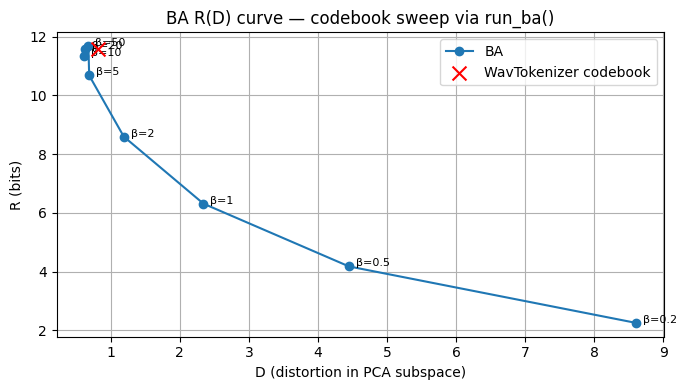

In [15]:
# Cell 5: R(D) plot
df_plot = df.sort_values("D")

plt.figure(figsize=(7, 4))
plt.plot(df_plot["D"], df_plot["R_bits"], marker="o", label="BA")
for _, r in df_plot.iterrows():
    plt.text(r["D"], r["R_bits"], f"  \u03b2={r['beta']:g}", fontsize=8)
plt.scatter([D_wt], [H_wt], marker="x", color="red", s=100, zorder=5,
            label="WavTokenizer codebook")
plt.xlabel("D (distortion in PCA subspace)")
plt.ylabel("R (bits)")
plt.title("BA R(D) curve — codebook sweep via run_ba()")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Project BA centroids from the sweep onto the visualization PCA
for r in results:
    Y_np = r["embed_new"].cpu().float().numpy()  # [M, D]
    Y_pca_full = pca6.transform(Y_np)            # [M, 6]
    r["Y_pca2"]  = Y_pca_full[:, 0:2]
    r["Y_pca34"] = Y_pca_full[:, 2:4]
    r["Y_pca56"] = Y_pca_full[:, 4:6]

print(f"Projected {len(rows)} BA codebooks onto PCA-6 basis.")

Projected 8 BA codebooks onto PCA-6 basis.


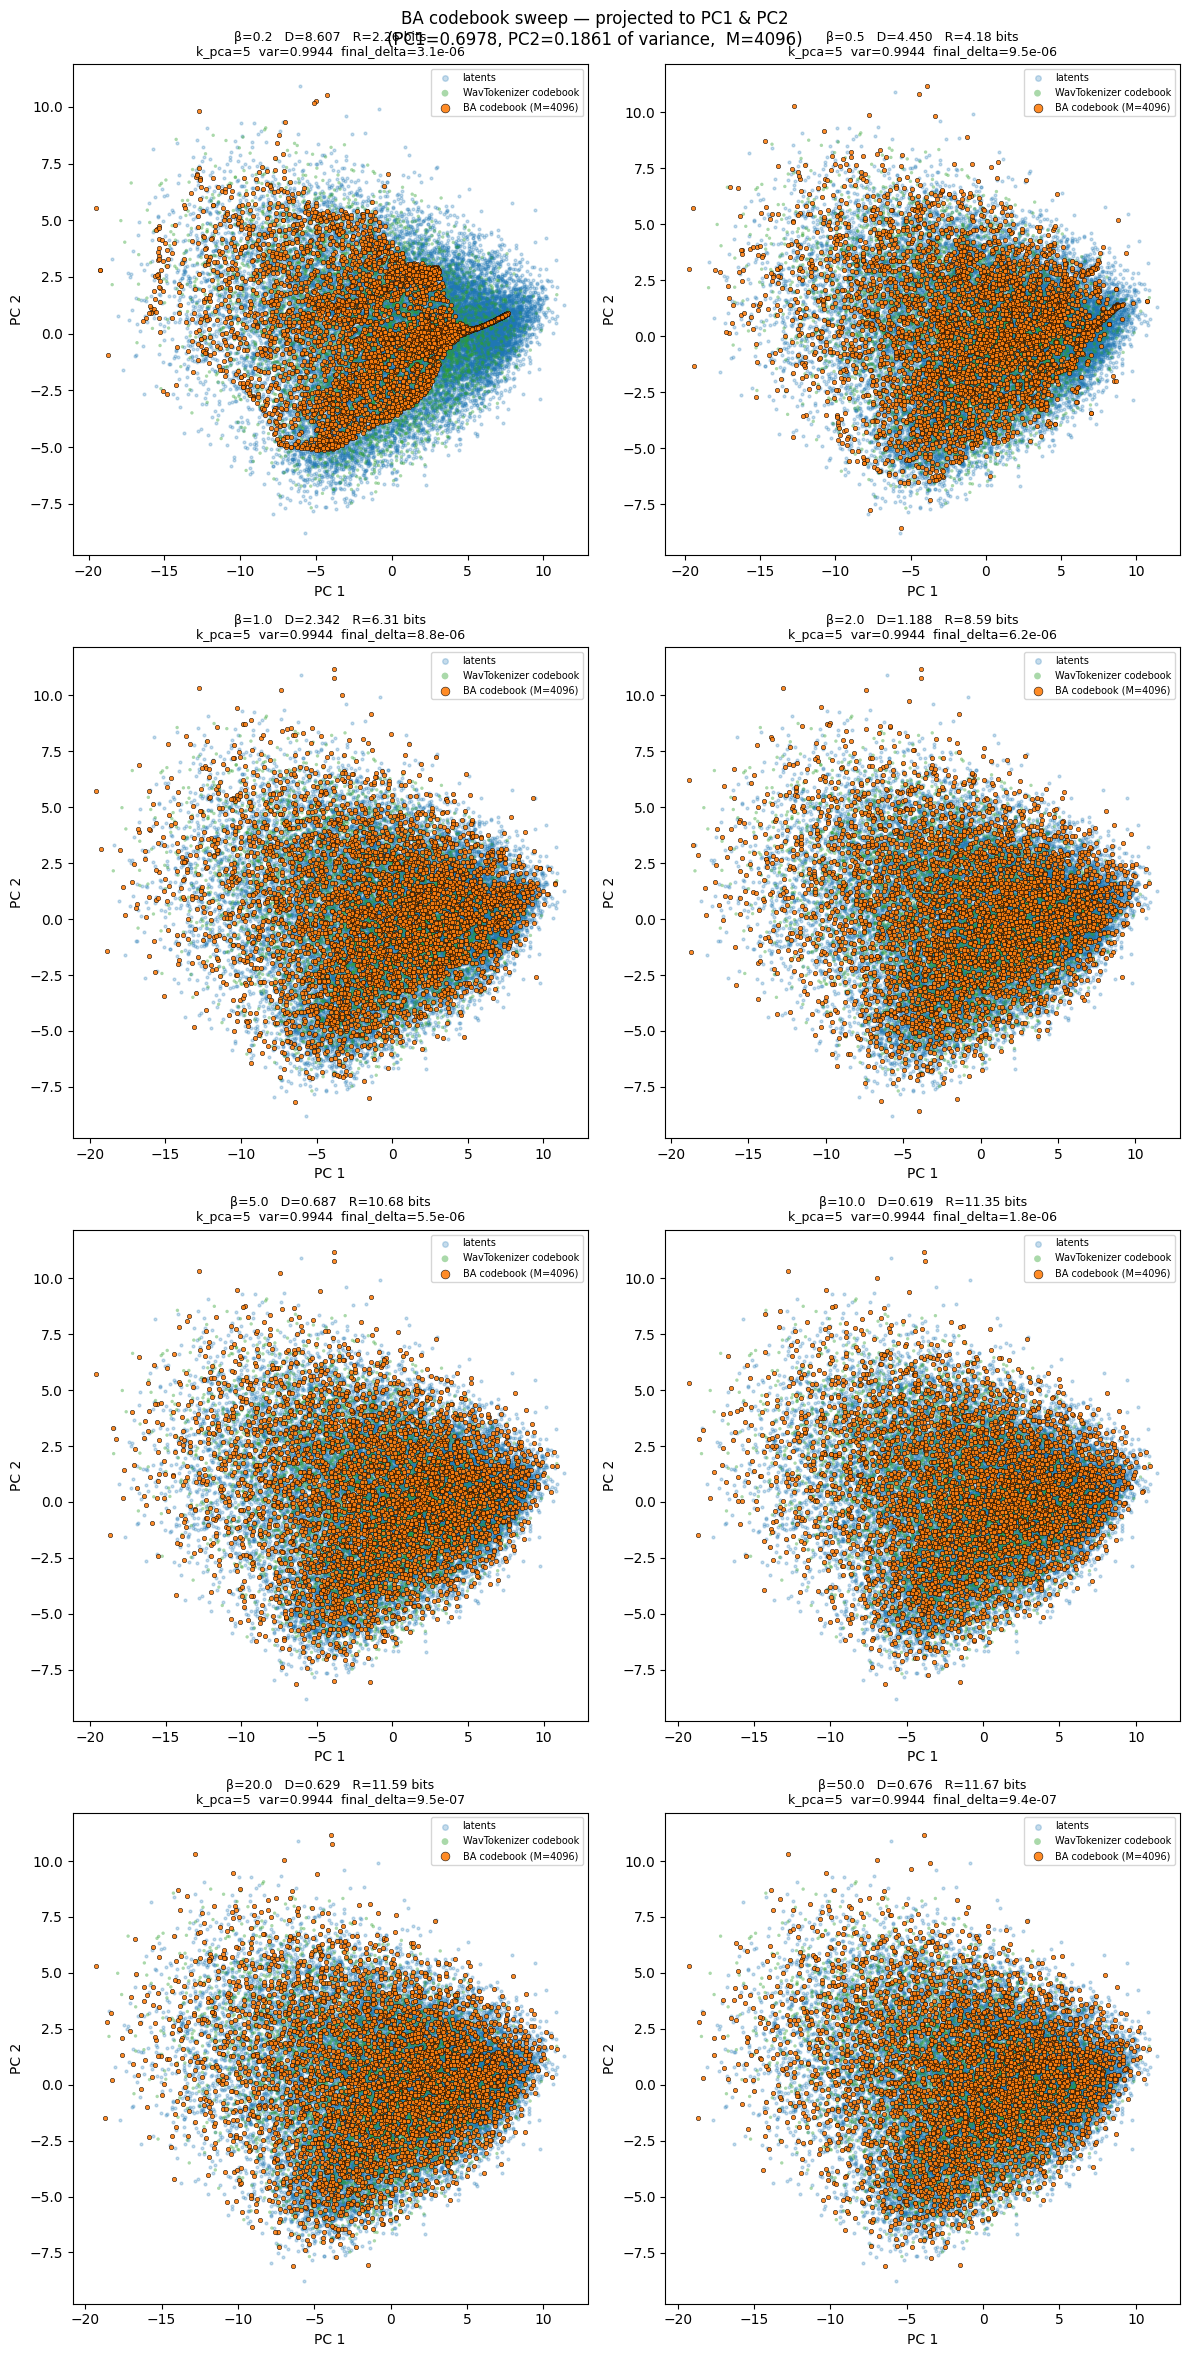

In [18]:
# Scatter plot: latents + BA codebook projected onto PC1 & PC2
n_rows = math.ceil(len(results) / 2)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

for ax, r in zip(axes.flat, results):
    ax.scatter(
        U_pca2[:, 0], U_pca2[:, 1],
        c="tab:blue", s=4, alpha=0.25, label="latents", rasterized=True,
    )
    ax.scatter(
        codebook_pca2[:, 0], codebook_pca2[:, 1],
        c="tab:green", s=6, alpha=0.4, edgecolors="none",
        label="WavTokenizer codebook", rasterized=True,
    )
    ax.scatter(
        r["Y_pca2"][:, 0], r["Y_pca2"][:, 1],
        c="tab:orange", s=10, alpha=0.9, edgecolors="k", linewidths=0.4,
        label=f"BA codebook (M={M})", zorder=5,
    )
    ax.set_title(
        f"\u03b2={r['beta']}   D={r['D']:.3f}   R={r['R_bits']:.2f} bits\n"
        f"k_pca={r['k_pca']}  var={r['var_explained']:.4f}  final_delta={r['final_delta']:.1e}",
        fontsize=9,
    )
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(fontsize=7, markerscale=2)

evr = pca6.explained_variance_ratio_
fig.suptitle(
    f"BA codebook sweep — projected to PC1 & PC2\n"
    f"(PC1={evr[0]:.4f}, PC2={evr[1]:.4f} of variance,  M={M})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

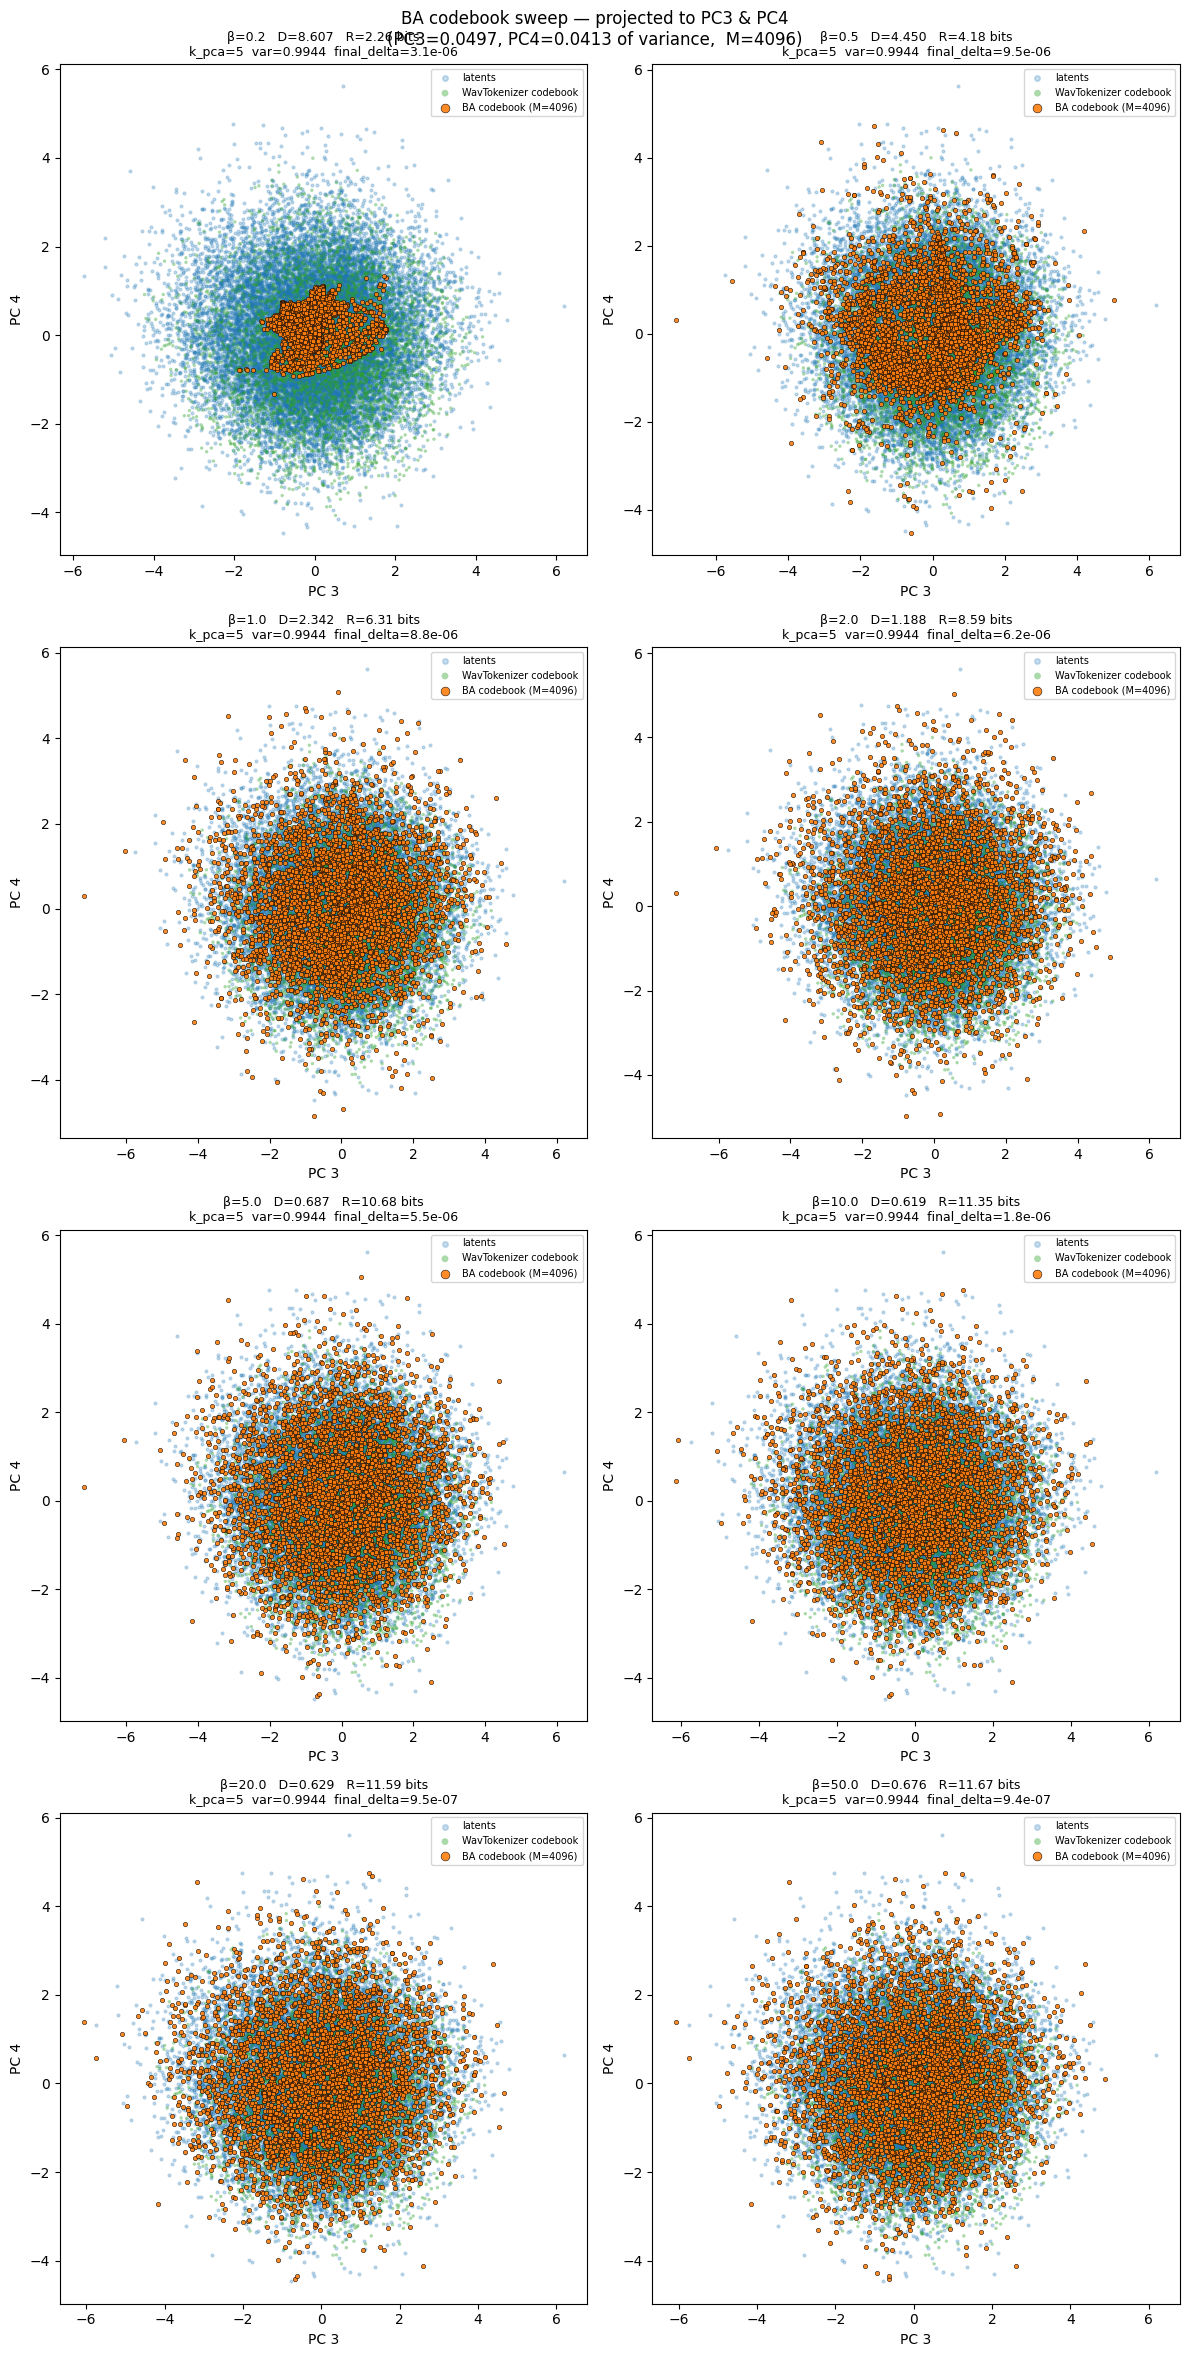

In [19]:
# Scatter plot: latents + BA codebook projected onto PC3 & PC4
n_rows = math.ceil(len(results) / 2)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

for ax, r in zip(axes.flat, results):
    ax.scatter(
        U_pca34[:, 0], U_pca34[:, 1],
        c="tab:blue", s=4, alpha=0.25, label="latents", rasterized=True,
    )
    ax.scatter(
        codebook_pca34[:, 0], codebook_pca34[:, 1],
        c="tab:green", s=6, alpha=0.4, edgecolors="none",
        label="WavTokenizer codebook", rasterized=True,
    )
    ax.scatter(
        r["Y_pca34"][:, 0], r["Y_pca34"][:, 1],
        c="tab:orange", s=10, alpha=0.9, edgecolors="k", linewidths=0.4,
        label=f"BA codebook (M={M})", zorder=5,
    )
    ax.set_title(
        f"\u03b2={r['beta']}   D={r['D']:.3f}   R={r['R_bits']:.2f} bits\n"
        f"k_pca={r['k_pca']}  var={r['var_explained']:.4f}  final_delta={r['final_delta']:.1e}",
        fontsize=9,
    )
    ax.set_xlabel("PC 3")
    ax.set_ylabel("PC 4")
    ax.legend(fontsize=7, markerscale=2)

evr = pca6.explained_variance_ratio_
fig.suptitle(
    f"BA codebook sweep — projected to PC3 & PC4\n"
    f"(PC3={evr[2]:.4f}, PC4={evr[3]:.4f} of variance,  M={M})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

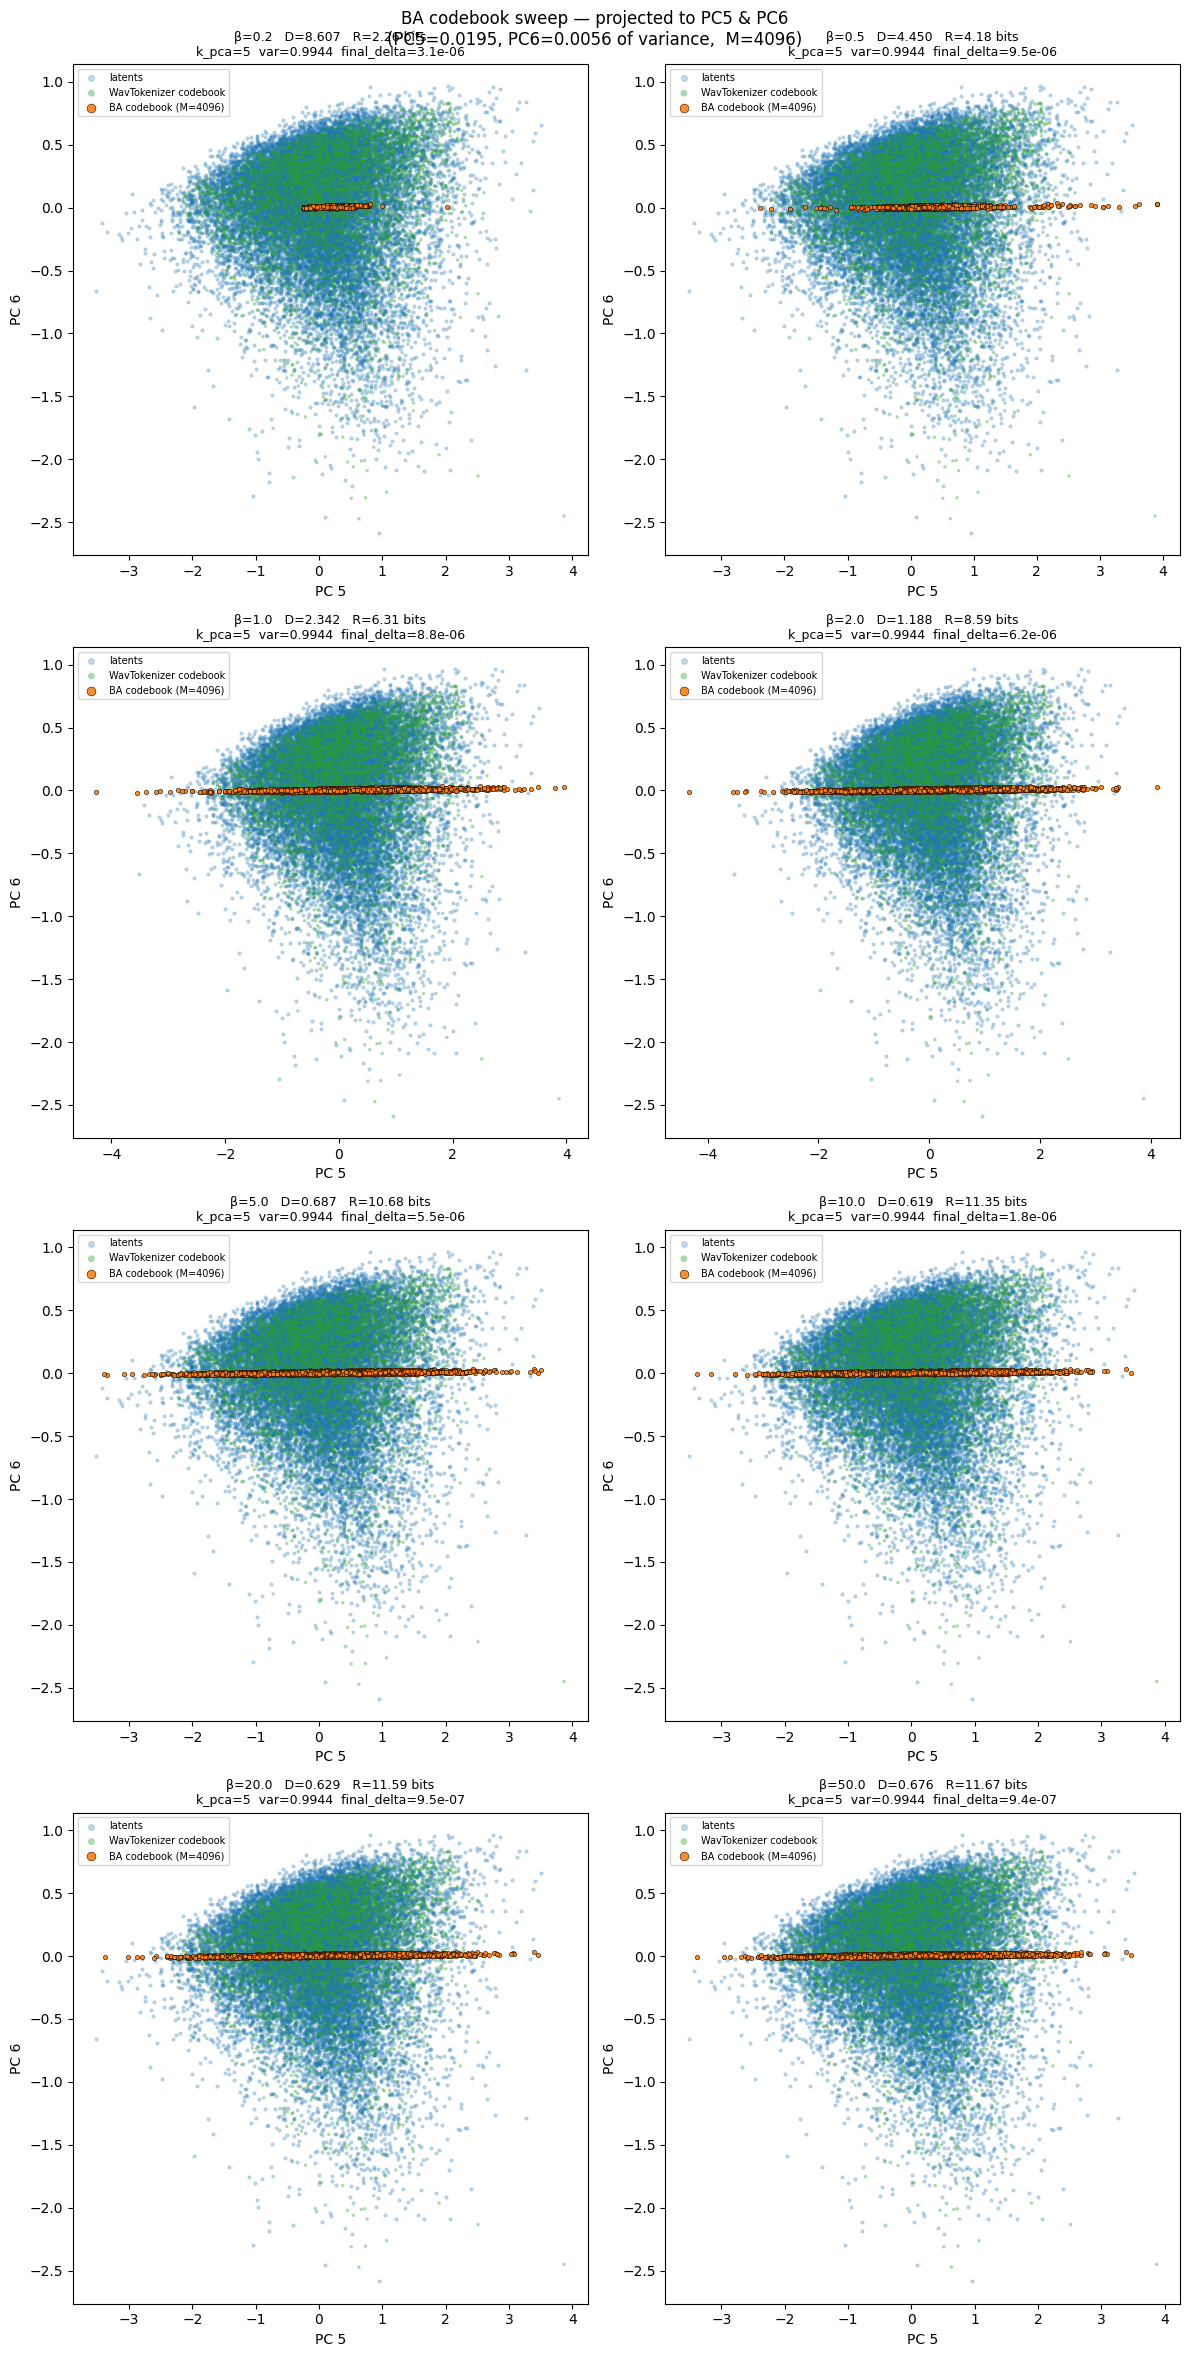

In [20]:
# Scatter plot: latents + BA codebook projected onto PC5 & PC6
n_rows = math.ceil(len(results) / 2)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

for ax, r in zip(axes.flat, results):
    ax.scatter(
        U_pca56[:, 0], U_pca56[:, 1],
        c="tab:blue", s=4, alpha=0.25, label="latents", rasterized=True,
    )
    ax.scatter(
        codebook_pca56[:, 0], codebook_pca56[:, 1],
        c="tab:green", s=6, alpha=0.4, edgecolors="none",
        label="WavTokenizer codebook", rasterized=True,
    )
    ax.scatter(
        r["Y_pca56"][:, 0], r["Y_pca56"][:, 1],
        c="tab:orange", s=10, alpha=0.9, edgecolors="k", linewidths=0.4,
        label=f"BA codebook (M={M})", zorder=5,
    )
    ax.set_title(
        f"\u03b2={r['beta']}   D={r['D']:.3f}   R={r['R_bits']:.2f} bits\n"
        f"k_pca={r['k_pca']}  var={r['var_explained']:.4f}  final_delta={r['final_delta']:.1e}",
        fontsize=9,
    )
    ax.set_xlabel("PC 5")
    ax.set_ylabel("PC 6")
    ax.legend(fontsize=7, markerscale=2)

evr = pca6.explained_variance_ratio_
fig.suptitle(
    f"BA codebook sweep — projected to PC5 & PC6\n"
    f"(PC5={evr[4]:.4f}, PC6={evr[5]:.4f} of variance,  M={M})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

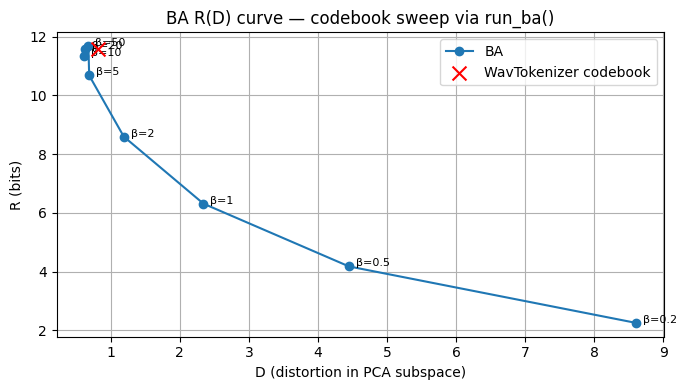

In [21]:
# Cell 5: R(D) plot
df_plot = df.sort_values("D")

plt.figure(figsize=(7, 4))
plt.plot(df_plot["D"], df_plot["R_bits"], marker="o", label="BA")
for _, r in df_plot.iterrows():
    plt.text(r["D"], r["R_bits"], f"  \u03b2={r['beta']:g}", fontsize=8)
plt.scatter([D_wt], [H_wt], marker="x", color="red", s=100, zorder=5,
            label="WavTokenizer codebook")
plt.xlabel("D (distortion in PCA subspace)")
plt.ylabel("R (bits)")
plt.title("BA R(D) curve — codebook sweep via run_ba()")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()